### Analysis of Analytical Latency Estimation

In [1]:
from inference import *
from inference_config import *
import matplotlib.pyplot as plt


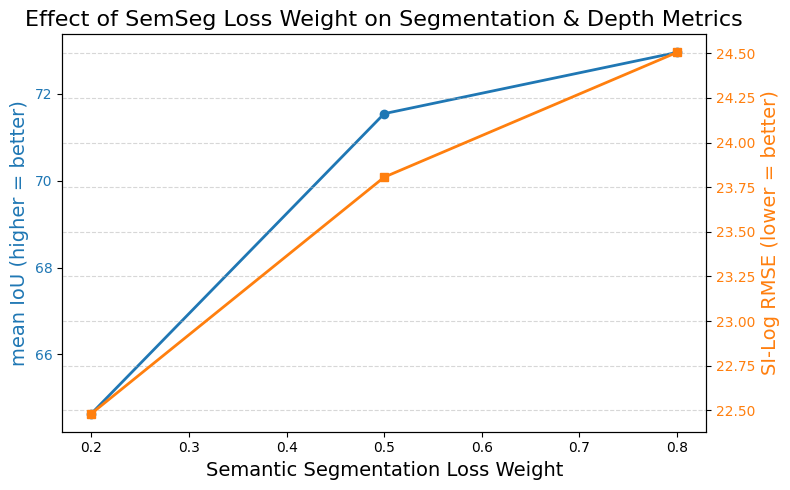

In [ ]:
# task 4 - adaptive depth estimation
epochs = [1,5]
SI_log_RMSE = [31.12324,19.85255]


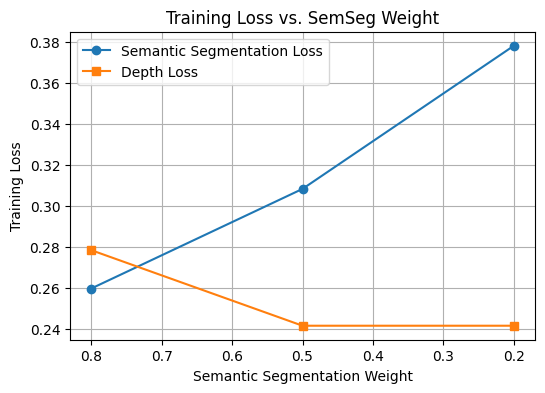

In [7]:
import matplotlib.pyplot as plt

# Data
semseg_weight = [0.8, 0.5, 0.2]
semseg_train_loss = [0.25956, 0.30832, 0.37836]
depth_train_loss = [0.27836, 0.24138, 0.24138]

# Plot
plt.figure(figsize=(6,4))
plt.plot(semseg_weight, semseg_train_loss, marker='o', label='Semantic Segmentation Loss')
plt.plot(semseg_weight, depth_train_loss, marker='s', label='Depth Loss')
plt.xlabel('Semantic Segmentation Weight')
plt.ylabel('Training Loss')
plt.title('Training Loss vs. SemSeg Weight')
plt.gca().invert_xaxis()  # optional: because weights are decreasing
plt.legend()
plt.grid(True)
plt.show()


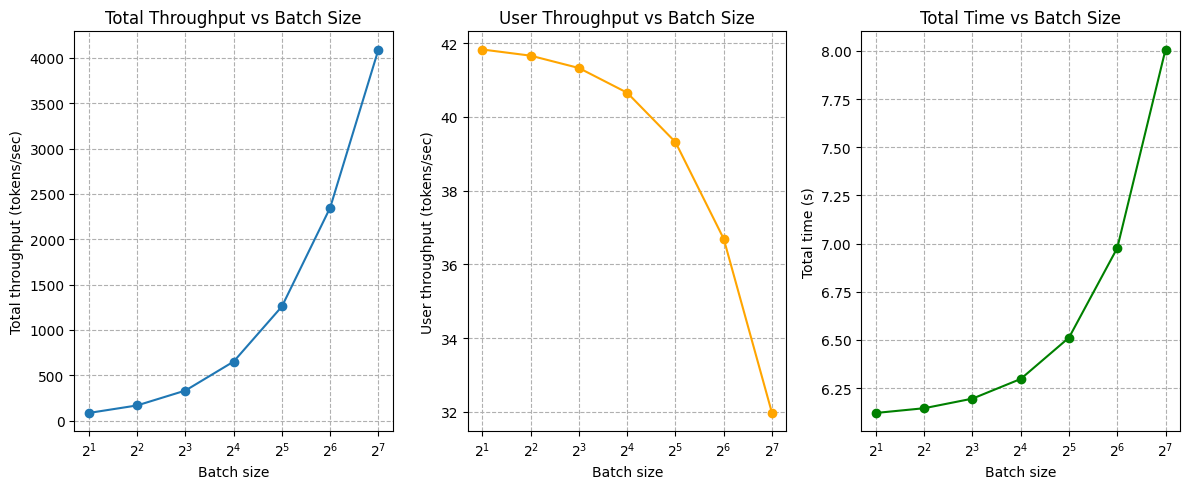

In [2]:
gpu = GPUConfig("gpu1",40*10e9,1.555*10e12,0.3*10e12,8e-06,300*10e12)
model = ModelConfig("llm1",70*10e9,80,8192,28672)
par = ParallelizeConfig(4)
dtype = DTypeConfig(2,2)


import numpy as np
import matplotlib.pyplot as plt

# Batch sizes: 2^1, 2^2, ..., 2^10
batch_sizes = np.logspace(1, 7, num=7, base=2).astype(int)

# Initialize your inference model
inference_model = Inference(gpu, model, par, dtype)

# Store results: rows = [total throughput, avg throughput, total_time]
pts = np.zeros((3, len(batch_sizes)))

for i, sz in enumerate(batch_sizes):
    batch = [Prompt(512, 256) for _ in range(sz)]
    
    total_tokens = sum([x.completion_tokens for x in batch])
    avg_tokens = np.mean([x.completion_tokens for x in batch])
    
    total_time = inference_model.forward(batch, kv_caching=True)
    
    pts[0, i] = total_tokens / total_time       # total throughput
    pts[1, i] = avg_tokens / total_time         # average throughput
    pts[2, i] = total_time                      # total time per batch

# --- Plotting ---
plt.figure(figsize=(12, 5))

# 1. Total throughput
plt.subplot(1, 3, 1)
plt.plot(batch_sizes, pts[0], marker='o')
plt.xscale('log', base=2)
plt.xlabel("Batch size")
plt.ylabel("Total throughput (tokens/sec)")
plt.title("Total Throughput vs Batch Size")
plt.grid(True, which='both', ls='--')

# 2. Average throughput
plt.subplot(1, 3, 2)
plt.plot(batch_sizes, pts[1], marker='o', color='orange')
plt.xscale('log', base=2)
plt.xlabel("Batch size")
plt.ylabel("User throughput (tokens/sec)")
plt.title("User Throughput vs Batch Size")
plt.grid(True, which='both', ls='--')

# 3. Total time per batch
plt.subplot(1, 3, 3)
plt.plot(batch_sizes, pts[2], marker='o', color='green')
plt.xscale('log', base=2)
plt.xlabel("Batch size")
plt.ylabel("Total time (s)")
plt.title("Total Time vs Batch Size")
plt.grid(True, which='both', ls='--')

plt.tight_layout()
plt.show()


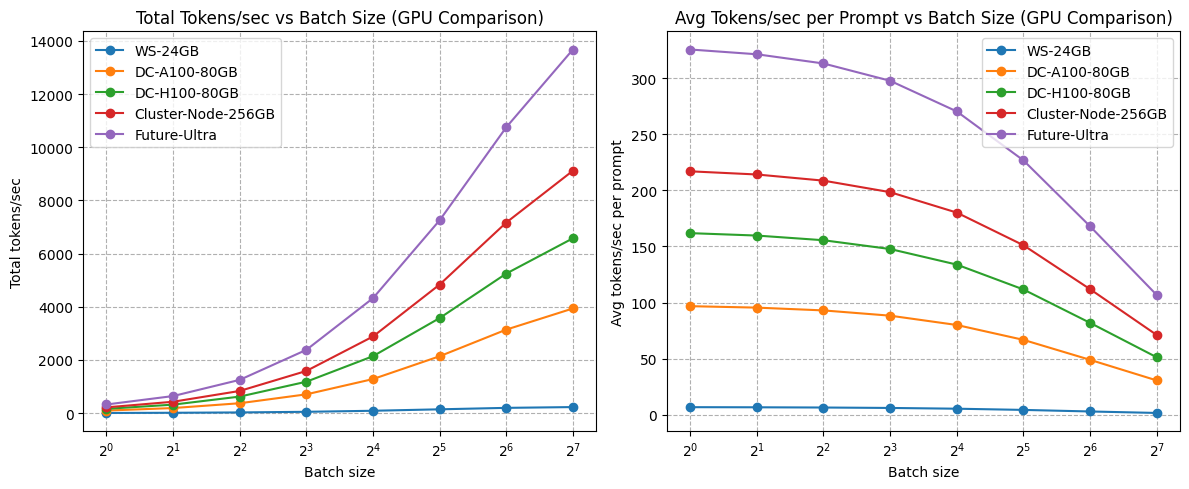

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- Define 5 GPU configurations (realistic/approx) ---
gpu_configs = [
    GPUConfig("WS-24GB", 24e9, 1e12, 0.2e12, 1e-5, 10e12),
    GPUConfig("DC-A100-80GB", 80e9, 2e12, 0.5e12, 5e-6, 300e12),
    GPUConfig("DC-H100-80GB", 80e9, 3.35e12, 0.8e12, 3e-6, 500e12),
    GPUConfig("Cluster-Node-256GB", 256e9, 4e12, 1.2e12, 2e-6, 800e12),
    GPUConfig("Future-Ultra", 512e9, 6e12, 2e12, 1e-6, 1200e12),
]

# --- Model / Parallelization / dtype ---
model = ModelConfig("llm1", 70e9, 80, 8192, 28672)
par = ParallelizeConfig(4)
dtype = DTypeConfig(2, 2)

# --- Batch sizes (powers of 2, feasible for 70B) ---
batch_sizes = np.array([1, 2, 4, 8, 16, 32, 64, 128])  # 2^0 to 2^6

# --- Store results ---
results = {}

for gpu in gpu_configs:
    inference_model = Inference(gpu, model, par, dtype)
    pts = np.zeros((3, len(batch_sizes)))  # total tokens/sec, avg tokens/sec, total_time
    
    for i, sz in enumerate(batch_sizes):
        batch = [Prompt(512, 256) for _ in range(int(sz))]  # 1000 prompt + 500 completion tokens
        total_tokens = sum([x.completion_tokens + x.prompt_tokens for x in batch])
        avg_tokens = np.mean([x.completion_tokens + x.prompt_tokens for x in batch])
        total_time = inference_model.forward(batch, kv_caching=True)
        
        pts[0, i] = total_tokens / total_time   # total tokens/sec
        pts[1, i] = avg_tokens / total_time     # avg tokens/sec per prompt
        pts[2, i] = total_time                  # total time per batch
    
    results[gpu.name] = pts

# --- Plotting ---
plt.figure(figsize=(12, 5))

# Total tokens/sec
plt.subplot(1, 2, 1)
for name, pts in results.items():
    plt.plot(batch_sizes, pts[0], marker='o', label=name)
plt.xscale('log', base=2)
plt.xlabel("Batch size")
plt.ylabel("Total tokens/sec")
plt.title("Total Tokens/sec vs Batch Size (GPU Comparison)")
plt.grid(True, which='both', ls='--')
plt.legend()

# Avg tokens/sec per prompt
plt.subplot(1, 2, 2)
for name, pts in results.items():
    plt.plot(batch_sizes, pts[1], marker='o', label=name)
plt.xscale('log', base=2)
plt.xlabel("Batch size")
plt.ylabel("Avg tokens/sec per prompt")
plt.title("Avg Tokens/sec per Prompt vs Batch Size (GPU Comparison)")
plt.grid(True, which='both', ls='--')
plt.legend()

plt.tight_layout()
plt.show()
